In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

In [2]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    gaussian_modified_density_drift_kernel, 
    noise_kernel_rotated,
    calculate_stats_complex
)

from src.numba_target import my_act_parallel_loop
from numba import cuda

Using single precision
Using C^1
Using Numba


## Trajectory history
Due to adaptive step size, different trajectories have different langevin dynamics. This means, that one trajectory may sample in a region with small drift magnitudes while another may encounter huge drifts. The first trajectory will have ada_step = 1 and the second ada_step << 1.  
If we want to study langevin dynamics - the evolution of an observable as langevin time progresses, we could look at the average over multiple trajectories. These however may diverge as mentioned above.  

Averaging at late langevin times only takes into account those trajs that had relativly big ada steps. These must have sampled close to small drift mag values. This introduces a bias 

In [3]:
config = Config(dims = [1], sigma=1, mean_ds_max = 100, interaction=1, trajs = int(1e4), steps = int(1e5), dt = 5e-4)
sim = ComplexLangevinSimulation(config)
sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=5e-5)
sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=0, auto_corr=1e-5)

In [4]:
min_real = 0
max_real = sim.dt*sim.steps

for idx in tqdm(range(sim.steps)):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()
        tr.update()
sim.finish()

100%|██████████| 100000/100000 [04:16<00:00, 390.09it/s]


In [5]:
# scipy routines
import numpy as np
from scipy.integrate import quad
from numba import jit

def n_moment(x, order):
    return x**order

# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part


# define exp val of n_moment wrt rho
@np.vectorize
def n_moment_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

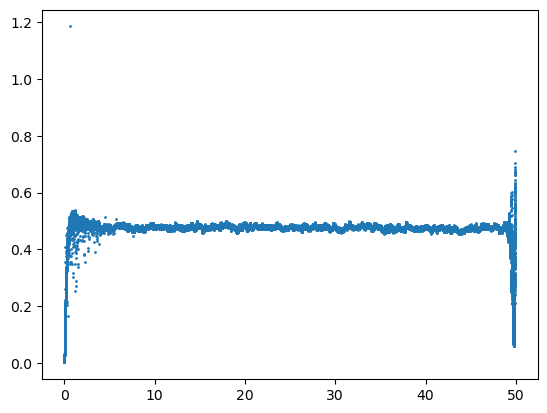

In [7]:
ana_res = n_moment_rho(2, sim.sigma, sim.interaction)
plt.scatter(sim.trackers["2_moment"].history_meas_times, sim.trackers["2_moment"].history_result.real, s = 1)

Text(0, 0.5, 'Number of participating trajectories')

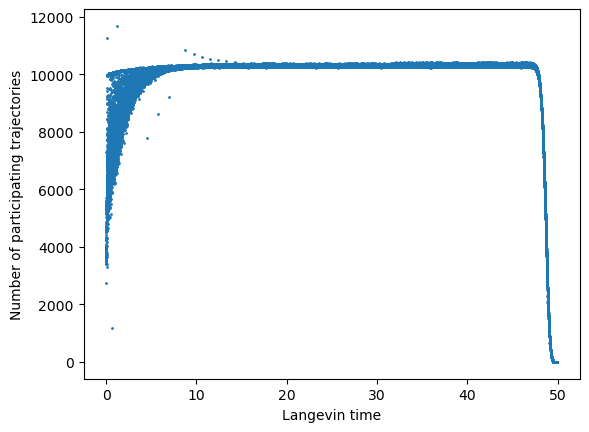

In [9]:
plt.scatter(sim.trackers["2_moment"].history_meas_times, sim.trackers["2_moment"].history_counter.real, s = 1)
plt.xlabel("Langevin time")
plt.ylabel("Number of participating trajectories")

Text(0, 0.5, 'Maximal Langevin time')

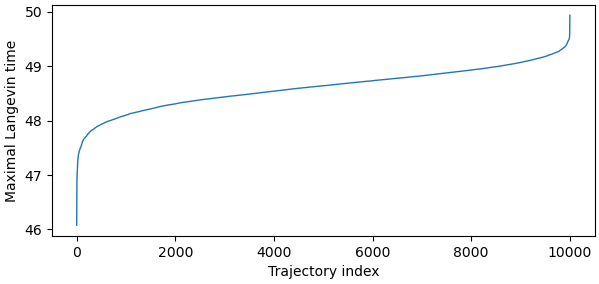

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
import scienceplots
plt.style.use('science')
ax.plot(np.linspace(0, sim.trajs, sim.trajs), np.sort(sim.langevin_time))
ax.set_xlabel("Trajectory index")
ax.set_ylabel("Maximal Langevin time")